.=# ANOVA

## Veneno en animales

Un laboratorio está investigando algunos tipos de venenos aplicando distintos tratamientos con estos en algunas especies animales (estos datos son ficticios).
Se nos proporciona un dataset que contiene 48 instancias y 3 variables:

- time: Tiempo necesario para mostrar síntomas
- poison: Tipo de veneno suministrado: 1, 2 y 3
- treat: Tipo de tratamiento utilizado: A, B, C y D

Se pretende investigar si el tipo de veneno subministrado, el tipo de tratamiento o ambos influyen en el tiempo necesario para mostrar síntomas.

### Condiciones para aplicar ANOVA

- Independencia
- Normalidad
- Homoscedasticidad

[link text](https://)### Lectura e inspección de los datos

In [1]:
# install.packages("dplyr")

In [6]:
datos <- read.csv("../data/Poison_and_treat.txt")

# Ver estructura
head(datos)
colnames(datos)

,X,time,poison,treat
,<int>,<dbl>,<int>,<chr>
1,1,0.31,1,A
2,2,0.45,1,A
3,3,0.46,1,A
4,4,0.43,1,A
5,5,0.36,2,A
6,6,0.29,2,A


[1] "X"      "time"   "poison" "treat"

In [7]:
# Eliminar columna X
library(dplyr)
datos <- select(datos, -X)

# Verificar
head(datos)
str(datos)
sum(is.na(datos))

,time,poison,treat
,<dbl>,<int>,<chr>
1,0.31,1,A
2,0.45,1,A
3,0.46,1,A
4,0.43,1,A
5,0.36,2,A
6,0.29,2,A


'data.frame':	48 obs. of  3 variables:
 $ time  : num  0.31 0.45 0.46 0.43 0.36 0.29 0.4 0.23 0.22 0.21 ...
 $ poison: int  1 1 1 1 2 2 2 2 3 3 ...
 $ treat : chr  "A" "A" "A" "A" ...


[1] 0

[link text](https://)Lo primero que haremos será cargar los datos y echarles un primer vistazo.

Comprobamos que tenemos 4 variables: X, time, poison y treat. La primera variable no nos sirve puesto que es un identificador de instancia, así que deberemos eliminarla.

También comprobamos si hay datos faltantes.

In [9]:
# datos <- dplyr::select(datos, -'X')
# head(datos)
sum(is.na(datos))

[1] 0

Nuestra idea es ver si el tipo de veneno suministrado influye en el tiempo hasta que los sintomas son visibles. De la misma forma, queremos ver si el tratamiento influye.

Separamos los data sets y hacemos un resumen de cada tipo de veneno y de tratamiento.

In [10]:
datos_pois <- dplyr::select(datos, -'treat')
datos_treat <- dplyr::select(datos, -'poison')

summary(subset(datos_pois,poison=='1'))
summary(subset(datos_pois,poison=='2'))
summary(subset(datos_pois,poison=='3'))

summary(subset(datos_treat,treat=='A'))
summary(subset(datos_treat,treat=='B'))
summary(subset(datos_treat,treat=='C'))
summary(subset(datos_treat,treat=='D'))

      time            poison 
 Min.   :0.3100   Min.   :1  
 1st Qu.:0.4500   1st Qu.:1  
 Median :0.6250   Median :1  
 Mean   :0.6175   Mean   :1  
 3rd Qu.:0.7300   3rd Qu.:1  
 Max.   :1.1000   Max.   :1  

      time            poison 
 Min.   :0.2300   Min.   :2  
 1st Qu.:0.3575   1st Qu.:2  
 Median :0.4200   Median :2  
 Mean   :0.5444   Mean   :2  
 3rd Qu.:0.6350   3rd Qu.:2  
 Max.   :1.2400   Max.   :2  

      time            poison 
 Min.   :0.1800   Min.   :3  
 1st Qu.:0.2275   1st Qu.:3  
 Median :0.2700   Median :3  
 Mean   :0.2762   Mean   :3  
 3rd Qu.:0.3150   3rd Qu.:3  
 Max.   :0.3800   Max.   :3  

      time           treat          
 Min.   :0.1800   Length:12         
 1st Qu.:0.2275   Class :character  
 Median :0.3000   Mode  :character  
 Mean   :0.3142                     
 3rd Qu.:0.4075                     
 Max.   :0.4600                     

      time           treat          
 Min.   :0.2900   Length:12         
 1st Qu.:0.3775   Class :character  
 Median :0.6650   Mode  :character  
 Mean   :0.6767                     
 3rd Qu.:0.8900                     
 Max.   :1.2400                     

      time           treat          
 Min.   :0.2200   Length:12         
 1st Qu.:0.2475   Class :character  
 Median :0.3750   Mode  :character  
 Mean   :0.3925                     
 3rd Qu.:0.4425                     
 Max.   :0.7600                     

      time           treat          
 Min.   :0.3000   Length:12         
 1st Qu.:0.3525   Class :character  
 Median :0.5050   Mode  :character  
 Mean   :0.5342                     
 3rd Qu.:0.6725                     
 Max.   :1.0200                     

De buenas a primeras, vemos una diferencia en las medias dependiendo de la categoría, pero no podemos estar seguros hasta que veamos la varianza de estos datos.

## Primeras suposiciones

In [ ]:
library(dplyr)

datos_pois %>%
    group_by(poison) %>%
    summarize(media = mean(time), desv = sd(time))

datos_treat %>%
    group_by(treat) %>%
    summarize(media = mean(time), desv = sd(time))

poison,media,desv
<int>,<dbl>,<dbl>
1,0.617500,0.20942779
2,0.544375,0.28936641
3,0.276250,0.06227627


treat,media,desv
<chr>,<dbl>,<dbl>
A,0.3141667,0.1022882
B,0.6766667,0.3208323
C,0.3925000,0.1670125
D,0.5341667,0.2194397


Si representamos el histograma con los datos:

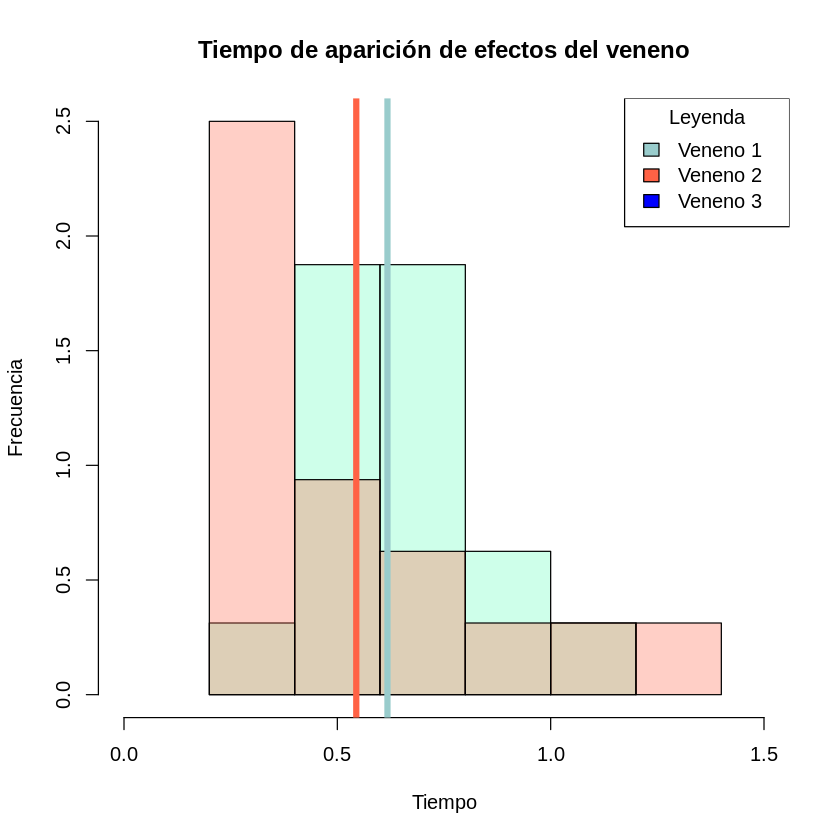

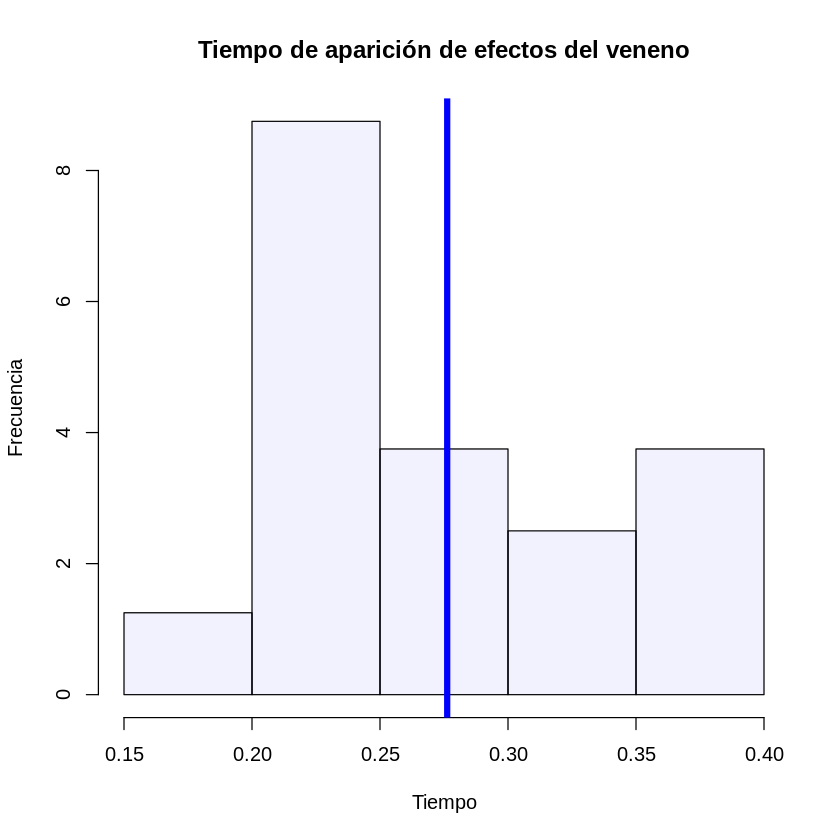

In [ ]:
hist(subset(datos_pois,poison=='1')[,'time'],
    col = rgb(0.369,1,0.737,0.3),
    main = 'Tiempo de aparición de efectos del veneno',
    freq = F,
    ylim = c(0,2.5),
    xlim = c(0,1.5),
    xlab='Tiempo',
    ylab = 'Frecuencia') #verde
hist(subset(datos_pois,poison=='2')[,'time'],
    col = rgb(1,0.384,0.272,0.3),
    add = T,
    ylim = c(0,2.5),
     xlim = c(0,1.5),
    freq = F) #naranja


abline(v = mean(subset(datos_pois,poison=='1')[,'time'])
       , col = rgb(0.6,0.8,0.8,1), lwd = 5)
abline(v = mean(subset(datos_pois,poison=='2')[,'time'])
       , col = rgb(1,0.384,0.272,1), lwd = 5)

legend(x = "topright", legend = c("Veneno 1", "Veneno 2", "Veneno 3"), fill = c(rgb(0.6,0.8,0.8,1), rgb(1,0.384,0.272,1),
       rgb(0,0,1,1)), title = "Leyenda")

hist(subset(datos_pois,poison=='3')[,'time'],
    col = rgb(0,0,1,0.05),
    main = 'Tiempo de aparición de efectos del veneno',
    add = F,
    freq = F,
    xlab='Tiempo',
    ylab = 'Frecuencia')
abline(v = mean(subset(datos_pois,poison=='3')[,'time'])
       , col = rgb(0,0,1,1), lwd = 5)

Hemos representado por separado el veneno 3 puesto que el tiempo de aparición de los efectos es mucho menor respecto a los otros dos venenos. Vemos que para el primer veneno los datos se situan alrededor de la media mientras que para los datos del veneno 2 y 3 están a la izquierda y a la derecha, respectivamente. Por lo que vemos que hay una diferencia de las medias en el tiempo de aparición de los efectos según el veneno subministrado.

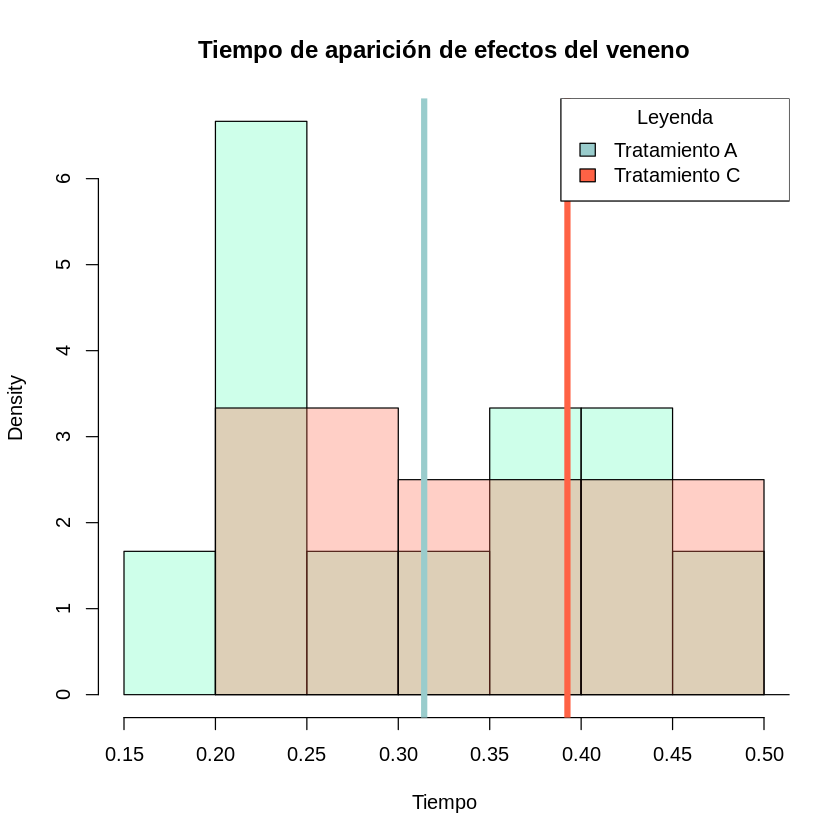

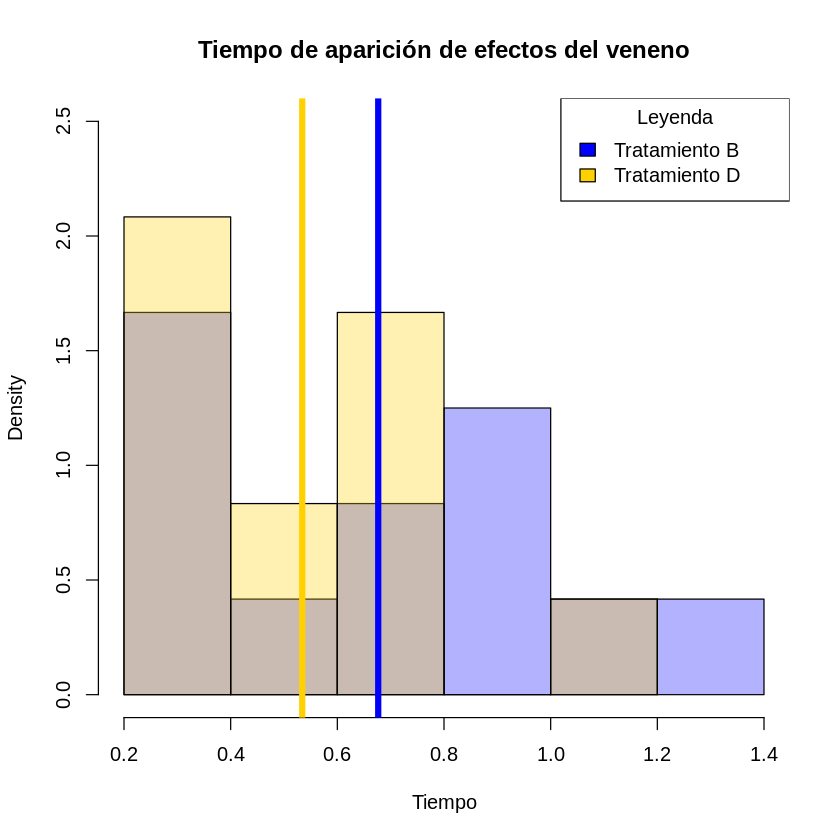

In [ ]:
hist(subset(datos_treat,treat=='A')[,'time'],
    col = rgb(0.369,1,0.737,0.3),
    main = 'Tiempo de aparición de efectos del veneno',
    freq = F,
    xlab='Tiempo') #verde
hist(subset(datos_treat,treat=='C')[,'time'],
    col = rgb(1,0.384,0.272,0.3),
    add = T,
    freq = F) #naranja

abline(v = mean(subset(datos_treat,treat=='A')[,'time'])
       , col = rgb(0.6,0.8,0.8,1), lwd = 5)
abline(v = mean(subset(datos_treat,treat=='C')[,'time'])
       , col = rgb(1,0.384,0.272,1), lwd = 5)

legend(x = "topright", legend = c("Tratamiento A", "Tratamiento C"), fill = c(rgb(0.6,0.8,0.8,1), rgb(1,0.384,0.272,1)),
       title = "Leyenda")

hist(subset(datos_treat,treat=='B')[,'time'],
    col = rgb(0,0,1,0.3),
    main = 'Tiempo de aparición de efectos del veneno',
    freq = F,
    xlab='Tiempo',
    ylim=c(0,2.5)) #azul
hist(subset(datos_treat,treat=='D')[,'time'],
    col = rgb(1,0.82,0,0.3),
    add = T,
    freq = F) #amarillo


abline(v = mean(subset(datos_treat,treat=='B')[,'time'])
       , col = rgb(0,0,1,1), lwd = 5)
abline(v = mean(subset(datos_treat,treat=='D')[,'time'])
       , col = rgb(1,0.82,0,1), lwd = 5)

legend(x = "topright", legend = c("Tratamiento B", "Tratamiento D"), fill = c(rgb(0,0,1,1), rgb(1,0.82,0,1)),
       title = "Leyenda")


De la misma forma que antes, vemos que en el caso del tratamiento, la distribución de los datos es muy distinta en función de cada clase así como la situación de la media. Cabe mencionar que para el tratamiento C, la distribución de los datos es uniforme.

Para continuar con nuestra investigación, usaremos un tipo de gráfico que se denomina violín:

<div>
<p style = 'text-align:center;'>
<img src="https://datavizcatalogue.com/ES/metodos/images/anatomy/SVG/diagrama_de_violin.svg" alt="JuveYell" width="300px">
</p>
</div>

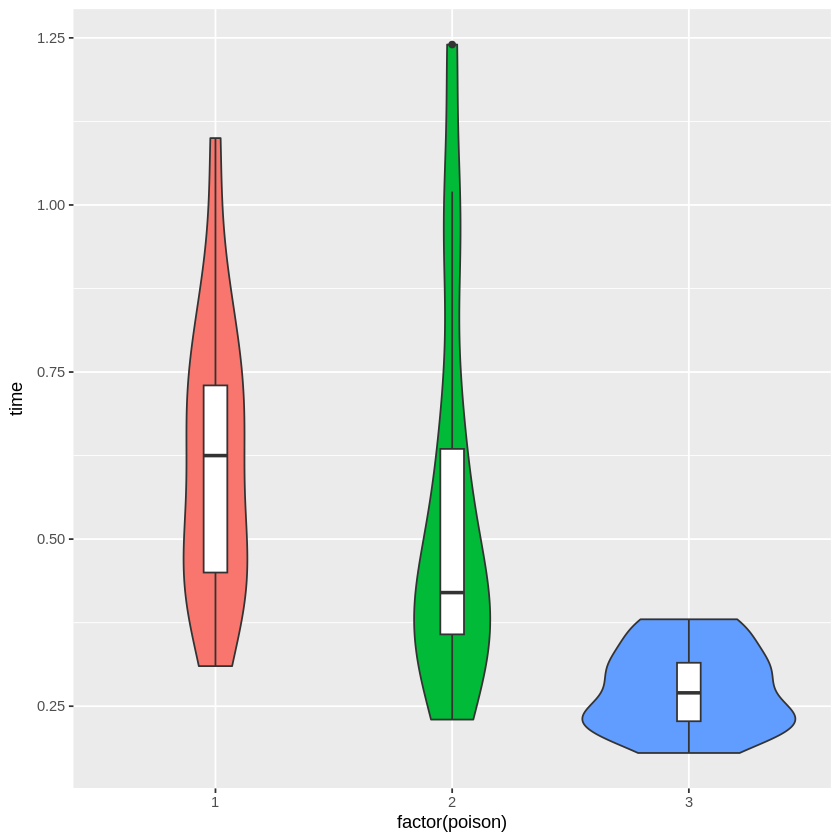

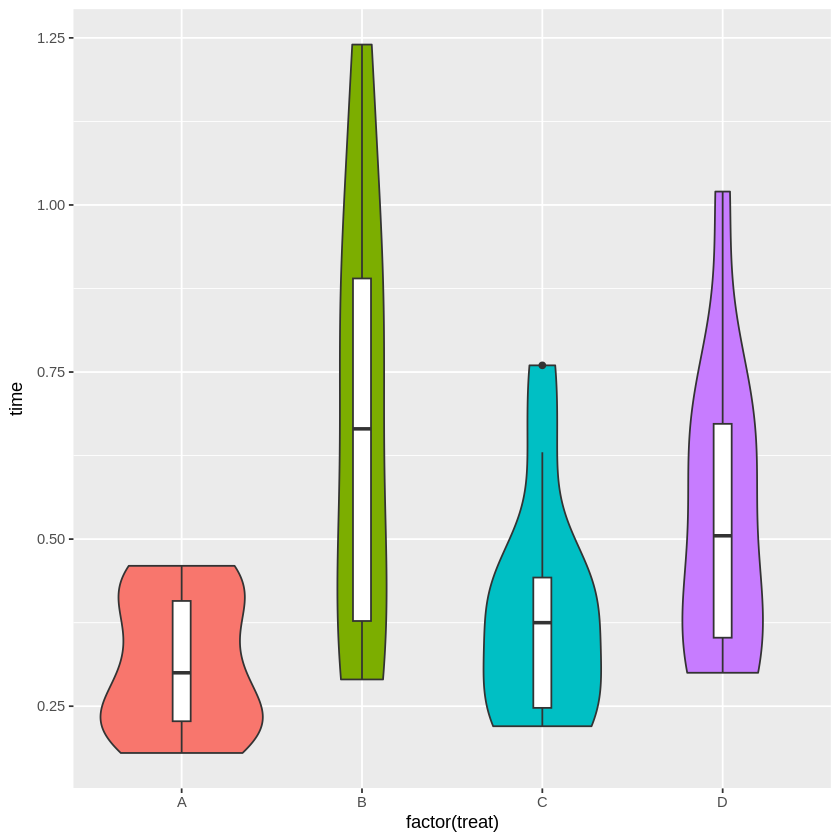

In [ ]:
library(ggplot2)

p = ggplot(datos_pois, aes(factor(poison), time))
p + geom_violin(aes(fill = factor(poison))) +
    theme(legend.position="none") +
    geom_boxplot(width=.1)

p = ggplot(datos_treat, aes(factor(treat), time))
p + geom_violin(aes(fill = factor(treat))) +
    theme(legend.position="none") +
    geom_boxplot(width=.1)

Viendo el gráfico de violín y la tabla de las medias y las desviaciones estándar por categoría se hace bastante notable la diferencia de las medias según la clase de dato, ya que las distribuciones son muy distintas para cada una y, además, la media se situa en un lugar diferente para cada una de ellas. Aún así, vamos a comprobar las condiciones para poder aplicar el test ANOVA

## Comprobación de condiciones

#### - Independencia en las muestras

Esto significa que cada muestra se ha tomado de forma independiente y que no depende de ninguna otra observación. Por ejemplo, si tenemos un saco y vamos sacando bolas sin reposición, la próxima observación dependerá de las bolas que hayamos sacado anteriormente. En nuestro caso, cada observación es independiente de la anterior.

#### - Normalidad

Y aquí llegamos al punto donde tenemos que comprobar que los datos sean normales. Llevando a cabo un test de normalidad vemos que en todas las clases excepto en el veneno del tipo 2 tenemos normalidad en los datos. Si se investiga un poco más, se ve claramente que estos datos no siguen una distribución normal. ¿Que podemos hacer? Podemos intentar aplicar la función logaritmo a los datos time y ver si conseguimos normalidad. De echo con la función logaritmo sí que logramos normalidad, así como con la raíz cuadrada. El problema que tenemos es que para ninguno de los dos casos tenemos *homoscedasticidad*, otra de las condiciones para poder aplicar ANOVA.

In [ ]:
shapiro.test(subset(datos_pois,poison=='1')[,'time'])
shapiro.test(subset(datos_pois,poison=='2')[,'time'])
shapiro.test(subset(datos_pois,poison=='3')[,'time'])

shapiro.test(subset(datos_treat,treat=='A')[,'time'])
shapiro.test(subset(datos_treat,treat=='B')[,'time'])
shapiro.test(subset(datos_treat,treat=='C')[,'time'])
shapiro.test(subset(datos_treat,treat=='D')[,'time'])


	Shapiro-Wilk normality test

data:  subset(datos_pois, poison == "1")[, "time"]
W = 0.93235, p-value = 0.2656



	Shapiro-Wilk normality test

data:  subset(datos_pois, poison == "2")[, "time"]
W = 0.85254, p-value = 0.01485



	Shapiro-Wilk normality test

data:  subset(datos_pois, poison == "3")[, "time"]
W = 0.93596, p-value = 0.3024



	Shapiro-Wilk normality test

data:  subset(datos_treat, treat == "A")[, "time"]
W = 0.90078, p-value = 0.1623



	Shapiro-Wilk normality test

data:  subset(datos_treat, treat == "B")[, "time"]
W = 0.93404, p-value = 0.4249



	Shapiro-Wilk normality test

data:  subset(datos_treat, treat == "C")[, "time"]
W = 0.88362, p-value = 0.09755



	Shapiro-Wilk normality test

data:  subset(datos_treat, treat == "D")[, "time"]
W = 0.89749, p-value = 0.1472


Haciendo una lectura rápida del test vemos que en todas las clases excepto en una tenemos normalidad en los datos. Veamos que pasa con los datos del veneno 2.

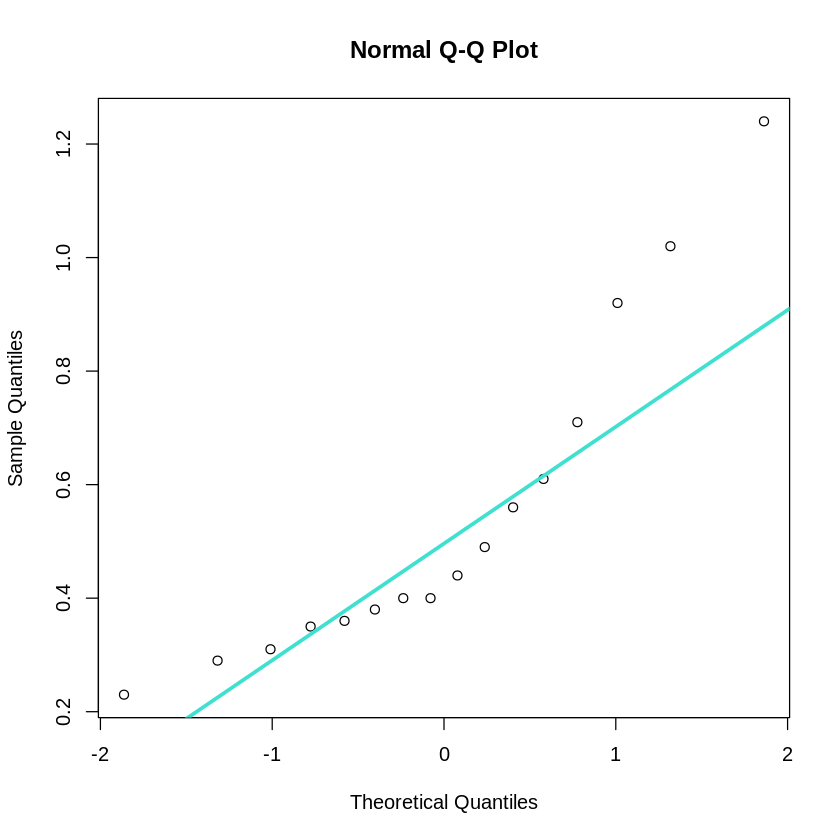

In [ ]:
qqnorm(subset(datos_pois,poison=='2')[,'time'])
qqline(subset(datos_pois,poison=='2')[,'time'] , col = "turquoise", lwd = 3)

Para comprobar la homoscedasticidad usamos el test de Bartlett donde la hipótesis nula es que las muestras tienen varianzas iguales mientras que la hipótesis alternativa es que no. Por lo que nos interesa que el p-valor del resultado sea mayor a 0.05, como en los test de normalidad.

In [ ]:
time_log <- log(datos['time'])
datos_log <- mutate(datos,time_log)
head(datos_log)

,time,poison,treat
,<dbl>,<int>,<chr>
1,-1.1711830,1,A
2,-0.7985077,1,A
3,-0.7765288,1,A
4,-0.8439701,1,A
5,-1.0216512,2,A
6,-1.2378744,2,A


In [ ]:
datos_pois_log <- dplyr::select(datos_log, -'treat')

shapiro.test(subset(datos_pois_log,poison=='2')[,'time'])

bartlett.test(time~poison, datos_log)


	Shapiro-Wilk normality test

data:  subset(datos_pois_log, poison == "2")[, "time"]
W = 0.95325, p-value = 0.5428



	Bartlett test of homogeneity of variances

data:  time by poison
Bartlett's K-squared = 7.667, df = 2, p-value = 0.02163


In [ ]:
time_sqrt <- sqrt(datos['time'])
datos_sqrt <- mutate(datos,time_sqrt)
head(datos_sqrt)

,time,poison,treat
,<dbl>,<int>,<chr>
1,0.5567764,1,A
2,0.6708204,1,A
3,0.6782330,1,A
4,0.6557439,1,A
5,0.6000000,2,A
6,0.5385165,2,A


In [ ]:
datos_pois_sqrt <- dplyr::select(datos_sqrt, -'treat')

shapiro.test(subset(datos_pois_sqrt,poison=='2')[,'time'])

bartlett.test(time~poison, datos_sqrt)


	Shapiro-Wilk normality test

data:  subset(datos_pois_sqrt, poison == "2")[, "time"]
W = 0.90916, p-value = 0.1128



	Bartlett test of homogeneity of variances

data:  time by poison
Bartlett's K-squared = 15.444, df = 2, p-value = 0.000443


Investigando he encontrado una manera de conseguir ambas cosas (homocedasticidad y normalidad). La manera de hacerlo sería usando el cosecante de la raíz cuadrado de los datos.

Esto puede llevarse a cabo gracias a las series de Taylor y el teorema fundamental de las distribuciones Normales:

- El teorema de Taylor, a grandes rasgos, viene a decir que cualquier función diferenciable en un punto concreto puede ser aproximada mediante una combinación lineal en este mismo punto.
- El teorema fundamental de las distribuciones normales indica que si una variable aleatoria es normal, entonces cualquier combinación lineal de esta, es normal.


La función raíz cuadrada es diferenciable para cualquier punto positivo, por lo que puede ser representada por una combinación lineal en nuestro caso. Si hacemos la raíz cuadrada del tiempo (el cual sigue una distribución normal para todos los tipos de veneno excepto para el 2) obtendremos datos normales para todos los tipos de veneno.

El cosecante (1/sin(x)) es diferenciable para cualquier punto excepto para los puntos en los que sin (x) es 0, por lo que puede ser representada por una combinación lineal en nuestro caso. Si hacemos el cosecante de la raíz cuadrada del tiempo (el cual sigue una distribución normal) obtendremos datos normales y, además, homoscedásticos.

In [ ]:
time_arcsinsqrt <- 1/sin(sqrt(datos['time']))
datos_arcsinsqrt <- mutate(datos,time_arcsinsqrt)
head(datos_arcsinsqrt)

,time,poison,treat
,<dbl>,<int>,<chr>
1,1.892319,1,A
2,1.608677,1,A
3,1.593834,1,A
4,1.640019,1,A
5,1.771032,2,A
6,1.949838,2,A


In [ ]:
datos_pois_arcsinsqrt <- dplyr::select(datos_arcsinsqrt, -'treat')
datos_treat_arcsinsqrt <- dplyr::select(datos_arcsinsqrt, -'poison')

shapiro.test(subset(datos_pois_arcsinsqrt,poison=='2')[,'time'])

bartlett.test(time~poison, datos_arcsinsqrt)


	Shapiro-Wilk normality test

data:  subset(datos_pois_arcsinsqrt, poison == "2")[, "time"]
W = 0.97685, p-value = 0.9336



	Bartlett test of homogeneity of variances

data:  time by poison
Bartlett's K-squared = 2.967, df = 2, p-value = 0.2268


Ahora ya tenemos nuestros datos normalizados y homocedásticos. Podemos aplicar el test ANOVA.



```
# This is formatted as code
```

## One-Way ANOVA

- $H_{0}$: Sucede cuando no existe diferencia entre los grupos o medias.
- $H_{1}$: Cuando se teoriza que existe una diferencia entre los grupos y las medias.

In [ ]:
anova_pois <- aov(time ~ poison
                  , datos_pois_arcsinsqrt)

summary(anova_pois)

anova_treat <- aov(time ~ treat
                  , datos_treat_arcsinsqrt)

summary(anova_treat)

            Df Sum Sq Mean Sq F value   Pr(>F)    
poison       1  2.535   2.535   42.27 5.12e-08 ***
Residuals   46  2.759   0.060                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

            Df Sum Sq Mean Sq F value   Pr(>F)    
treat        3  1.671  0.5571   6.768 0.000749 ***
Residuals   44  3.622  0.0823                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Vemos que debemos rechazar la hipotesis nula que dependiendo del tratamiento y del veneno suministrado, el tiempo en ver los efectos no varía. También es verdad que el valor F es mayor para el caso del veneno por lo que influiría más. Esto podemos acabar de confirmarlo con el Two-Way ANOVA:

## Two-Way ANOVA

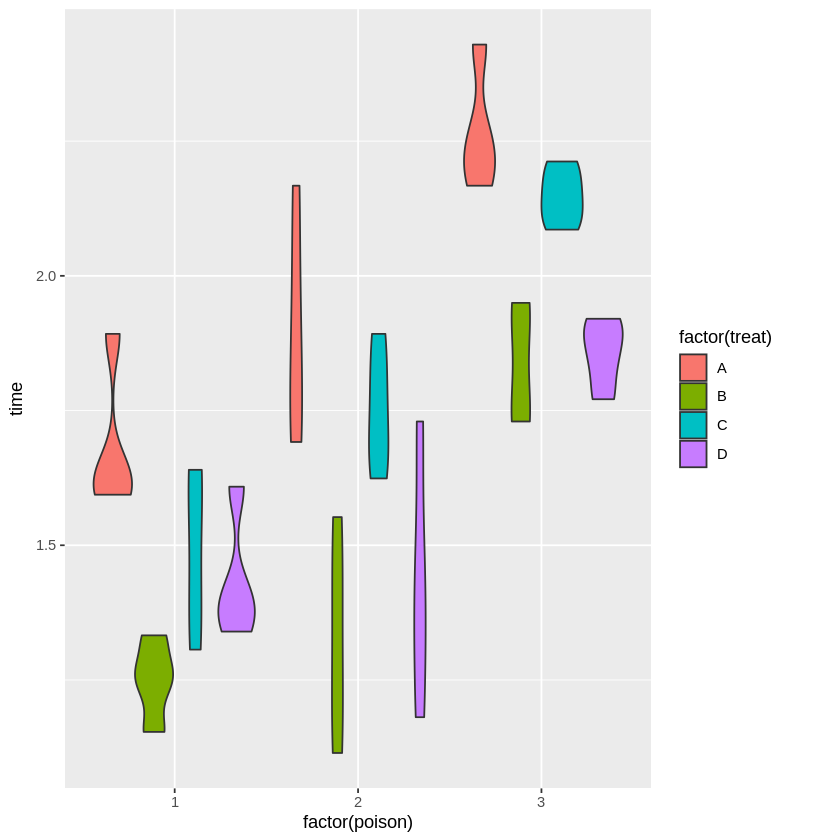

In [ ]:
p = ggplot(datos_arcsinsqrt, aes(factor(poison), time))
p + geom_violin(aes(fill = factor(treat)))


Aunque el gráfico de violín es poco claro dada la cantidad de clases, podemos ver que si que hay diferencias en las distribuciones y las medias, dependiendo del veneno y del tratamiento.

In [ ]:
tw_anova <- aov(time ~ poison * treat
                      , datos_arcsinsqrt)

summary(tw_anova)

             Df Sum Sq Mean Sq F value   Pr(>F)    
poison        1 2.5348  2.5348  98.707 2.33e-12 ***
treat         3 1.6714  0.5571  21.695 1.67e-08 ***
poison:treat  3 0.0602  0.0201   0.781    0.511    
Residuals    40 1.0272  0.0257                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Ahora ya podemos confirmar nuestras anteriores palabras. Ambos atributos influyen en el tiempo para ver los efectos del veneno suministrado, pero la variable que tiene más efecto es el veneno. Sin embargo, las dos variables juntas no influyen puesto que el valor de F es muy bajo y el p-valor es mucho mayor a 0.05, por lo que no podemos rechazar la hipotesis nula que las dos variables juntas no influyan en el tiempo.

## Referencias

Hrc.es. n.d. Pruebas para la homocesdasticidad. [online] Available at: <http://www.hrc.es/bioest/Anova_5.html>.

Sigüeñas, M., 2015. Pruebas de Normalidad. [online] Rpubs. Available at: <https://rpubs.com/MSiguenas/122473>.

Viva el Software Libre. n.d. Test de Bartlett para contrastar la homocedasticidad de más de 2 muestras usando R Commander. [online] Available at: <https://vivaelsoftwarelibre.com/test-de-bartlett-para-contrastar-la-homocedasticidad-de-mas-de-2-muestras-usando-r-commander/>.

Imágenes:

https://datavizcatalogue.com/ES/metodos/images/anatomy/SVG/diagrama_de_violin.svg